# Loading and plotting an interpolates spectrum at a given SpT
## The below eaxmple shows how to load an interpolated spectrum at a given SpT and plot it.

Text(0, 0.5, '')

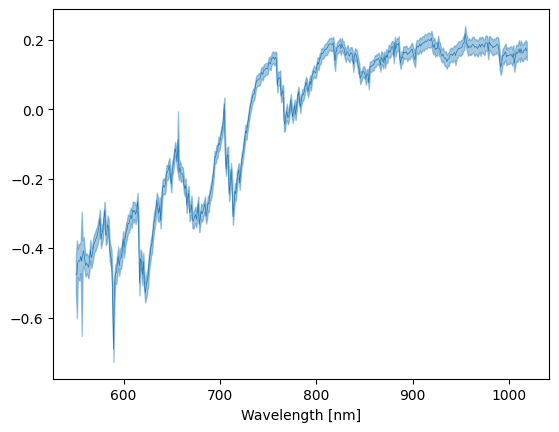

In [1]:
#Directory pointing towards and interpolated grid, they get istalled when pip nstalling the package, but if you just want 
dirInterp = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/src/frappe/models_grid/Interpolations/earlyK_norm731_200p_1000iter_rad2.5_WholeVIS/interp.npz'

import matplotlib.pyplot as plt
import frappe.FrappeHelper.PhotFeatures_Ray as pf
from frappe.FrappeHelper.spt_coding import spt_coding
import numpy as np


# First the class III object needs to be initialized
classIIIreadIn = pf.classIII(dirInterp)

# then load in the wavelength ranges used in the interterpolated grid
usedFeatures = classIIIreadIn.getUsedInterpFeat()
# compute the central wavelengths of the ranges:
wl = (usedFeatures[:,0]+usedFeatures[:,1])/2
# get the wl range used to normalize the spectra
normWLandWidth = classIIIreadIn.getUsedNormWl()

# we convert a SpT to a SpT code
sptCode = spt_coding('M3')
# then can sample the interpolated grid at a given SpT
features,errors = classIIIreadIn.getFeatsAtSpt_symetricErr(sptCode)
#The spectrum can then be plotted using
plt.figure()
plt.plot(wl,np.log10(features),'tab:blue',linewidth=.5)
plt.fill_between(wl,np.log10(features-errors) , np.log10(features +errors),color='tab:blue',alpha = 0.4)
plt.xlabel('Wavelength [nm]')
plt.ylabel('')



# Frappe also includes the neccecary tools to generate your own interpolated spectra based on X-Shooter. A description of how these methods work can be found in Claes et al. in 2024. Below an example is given of how this can be done. A future update will allow for other spectra to be included.

You have to either set a grid of interpoleted features from a table using the readInterpFeat() method or create a new grid by running extractFeaturesXS() and nonParamFit


2025-05-15 17:35:41,169	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:35:41,186	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper'.
2025-05-15 17:35:41,195	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:35:41,197	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740f.zip'.
2025-05-15 17:35:50,876	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:35:50,902	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper'.
2025-05-15 17:35:50,965	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:35:50,971	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740

<Figure size 1000x1000 with 0 Axes>

<Figure size 640x480 with 0 Axes>

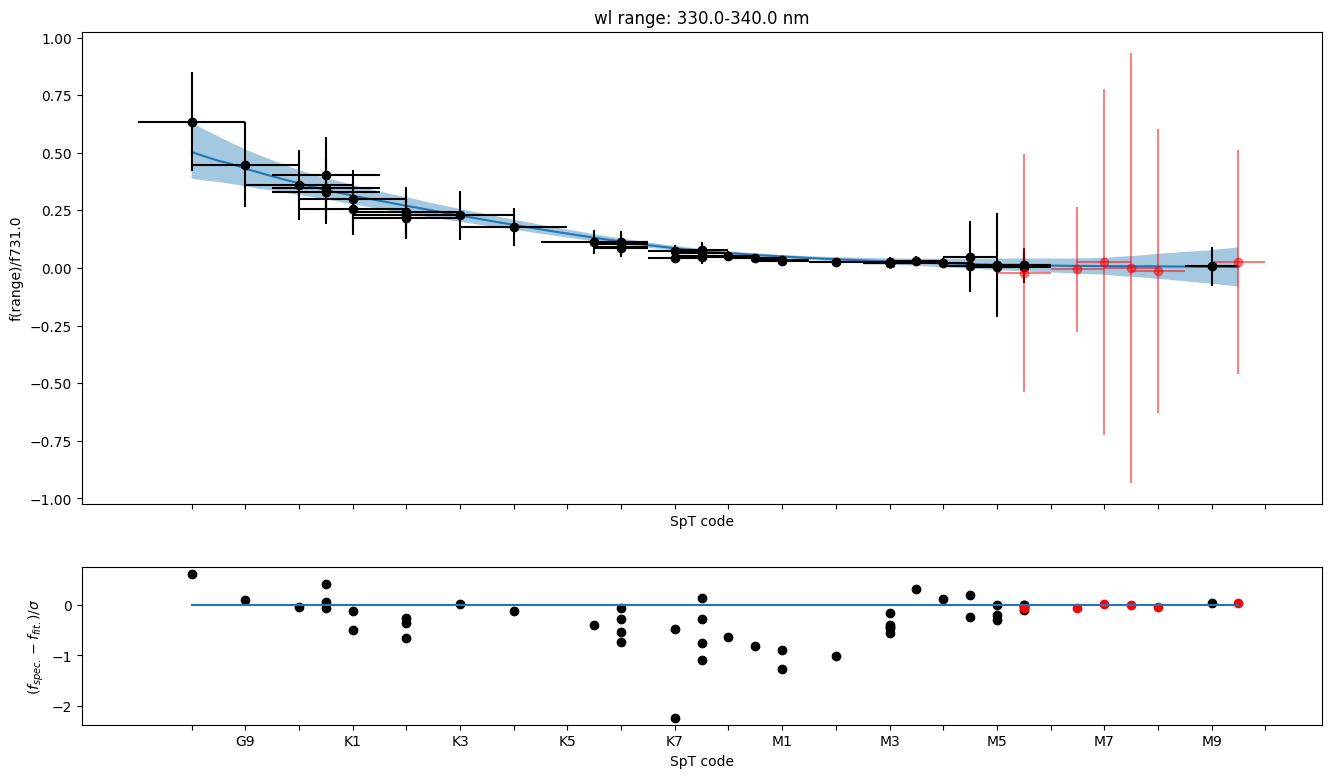

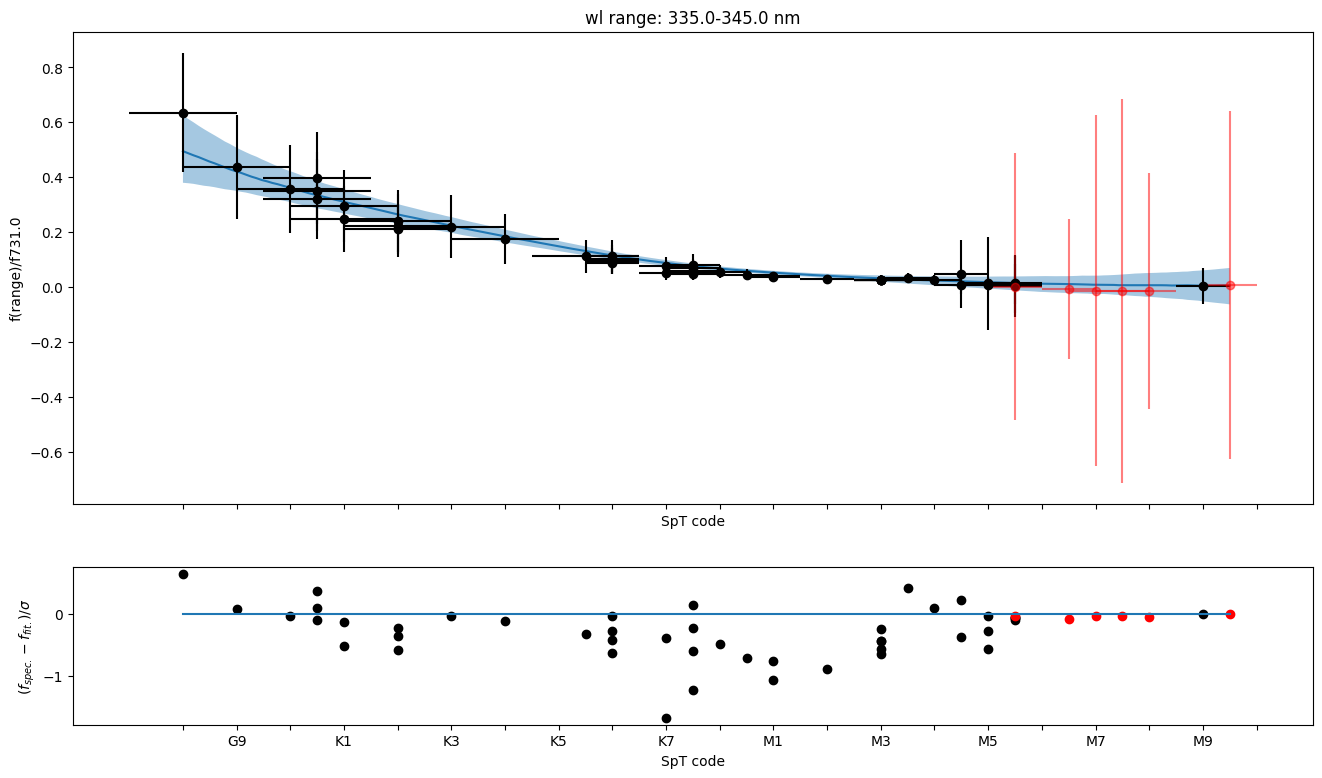

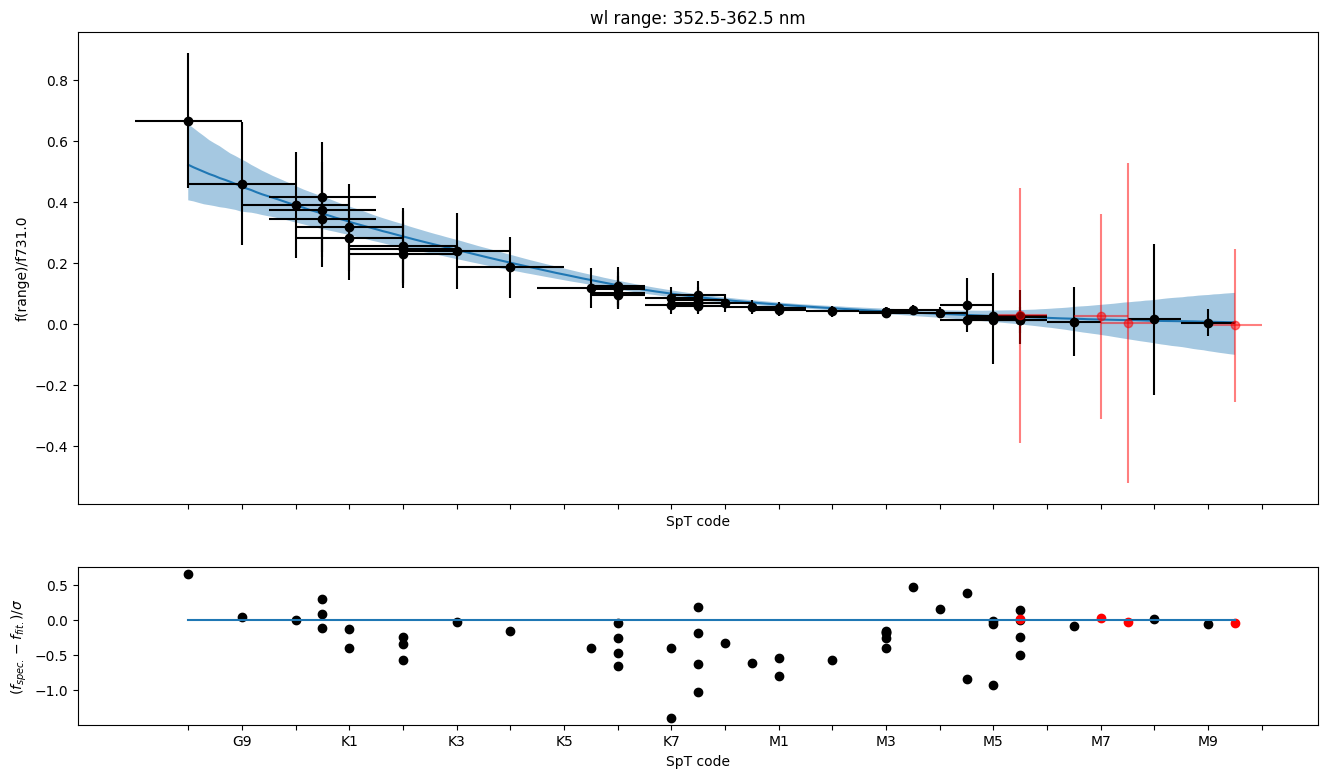

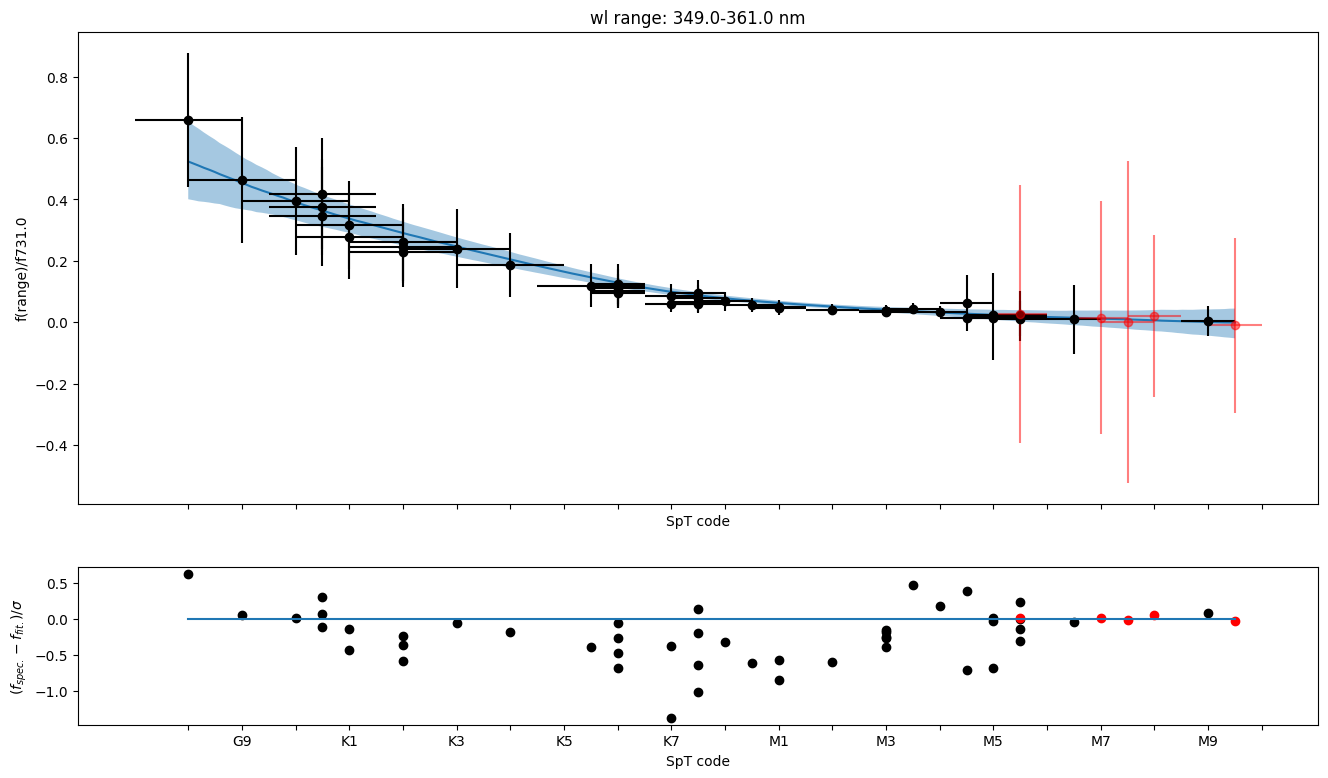

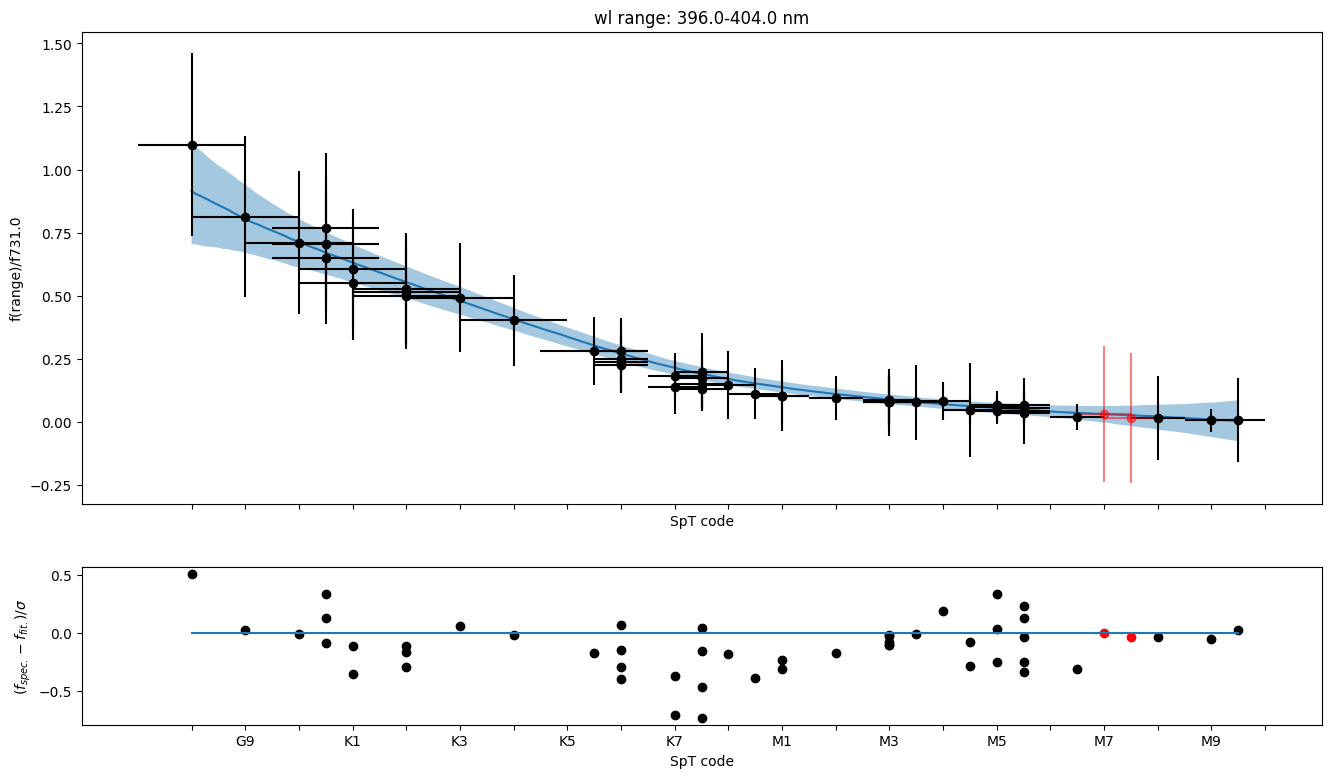

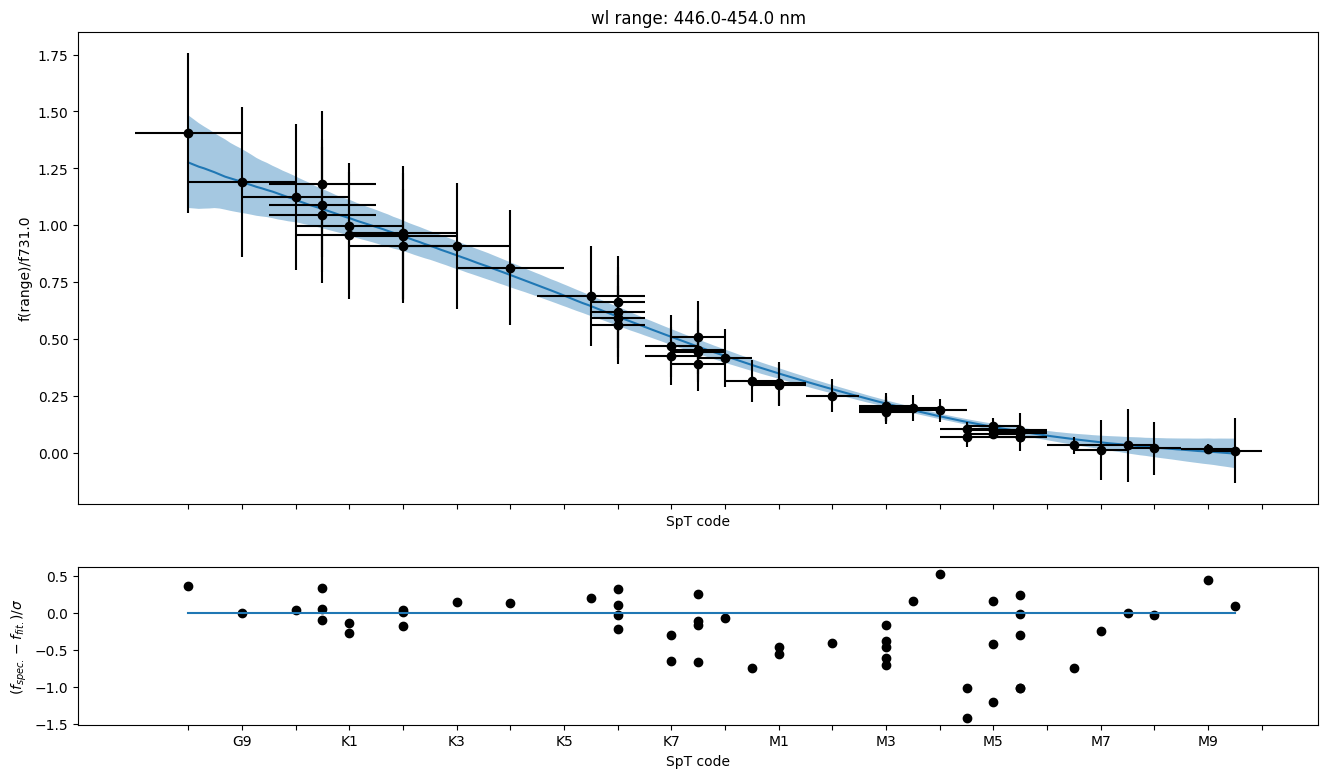

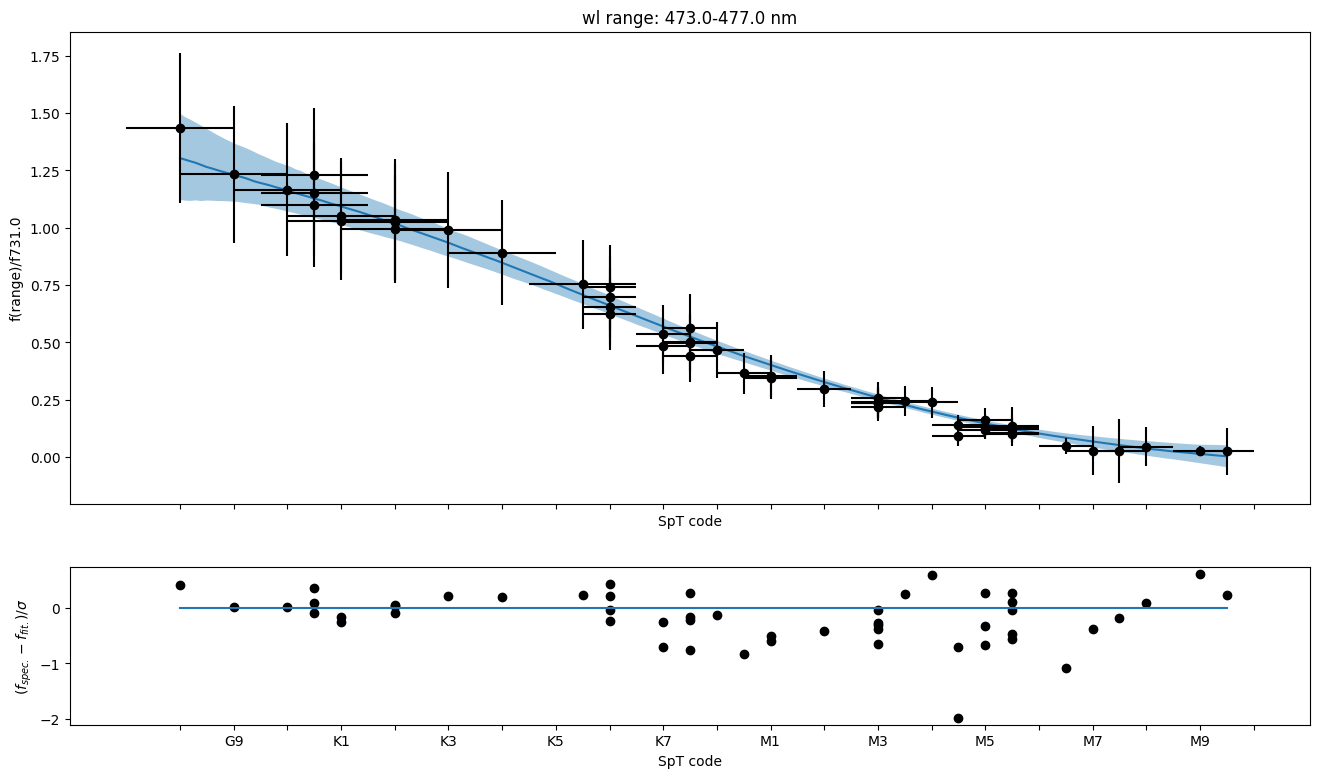

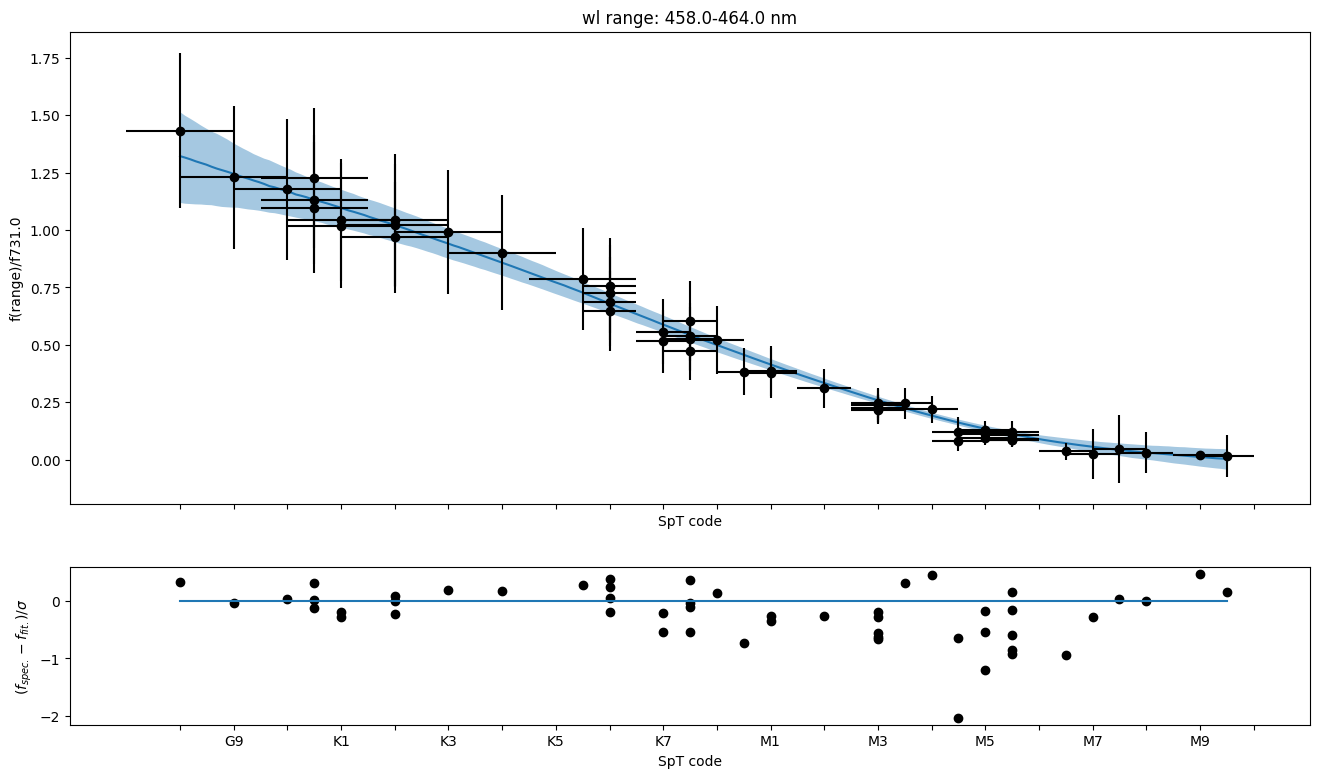

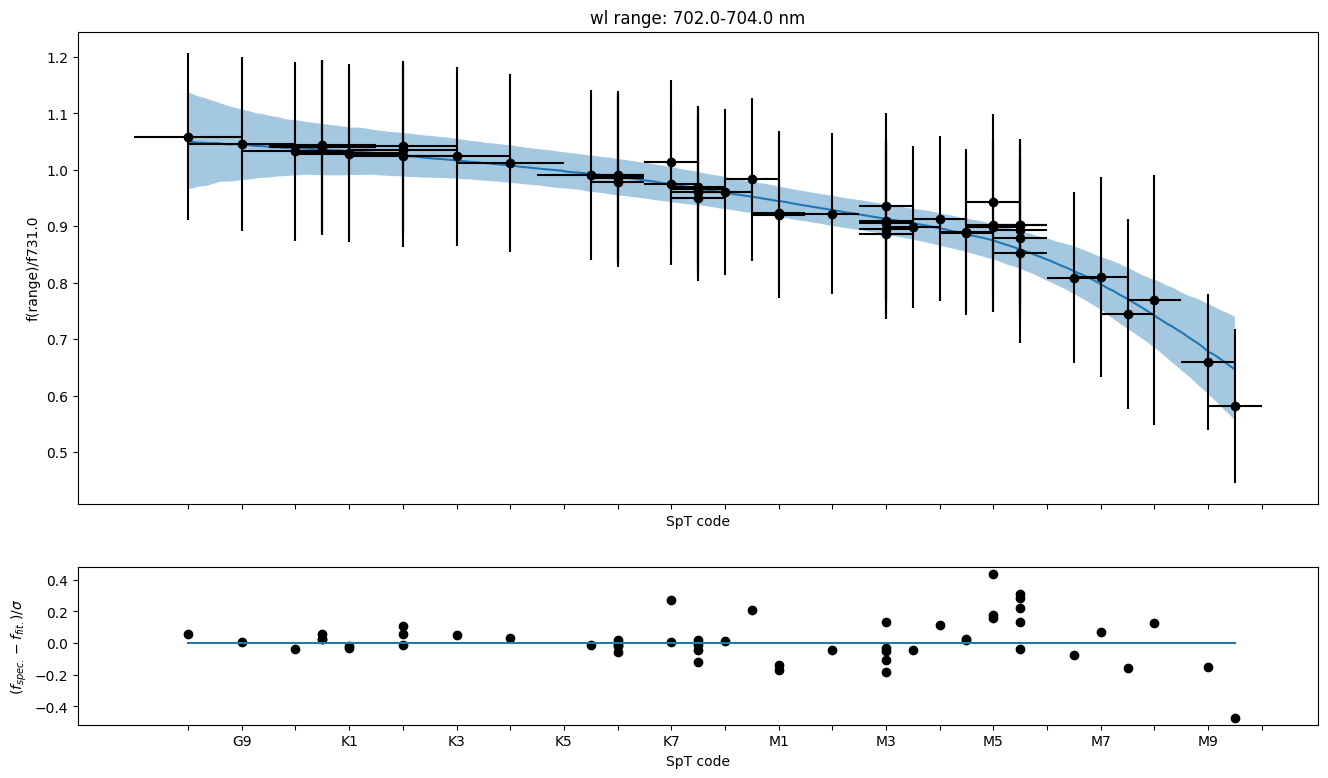

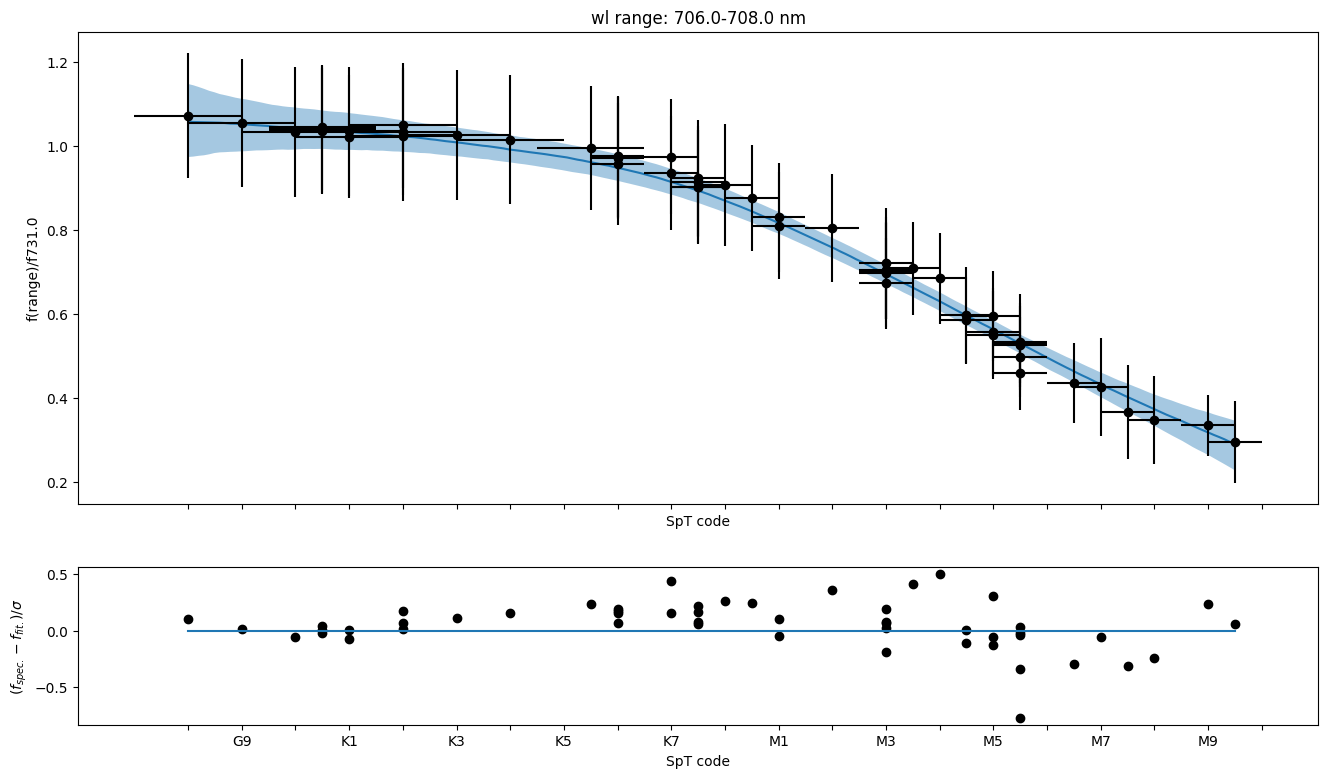

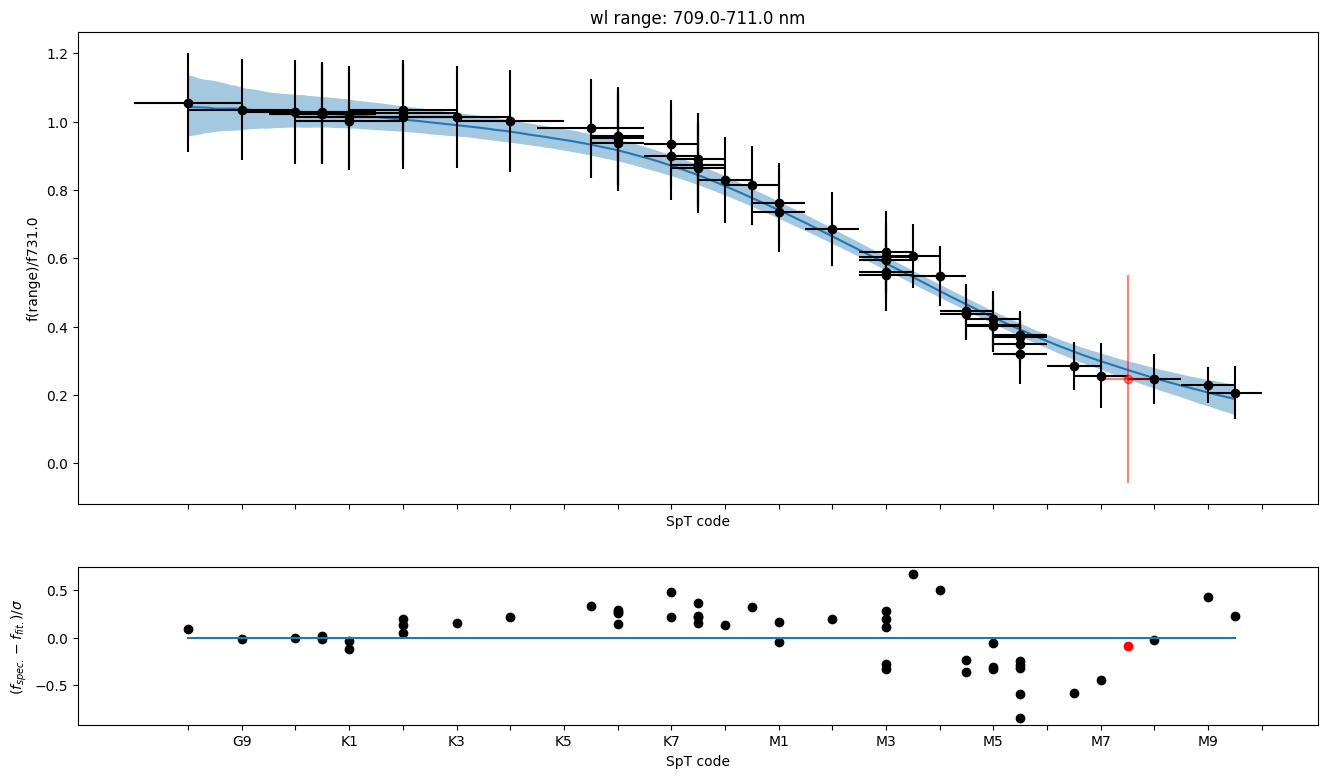

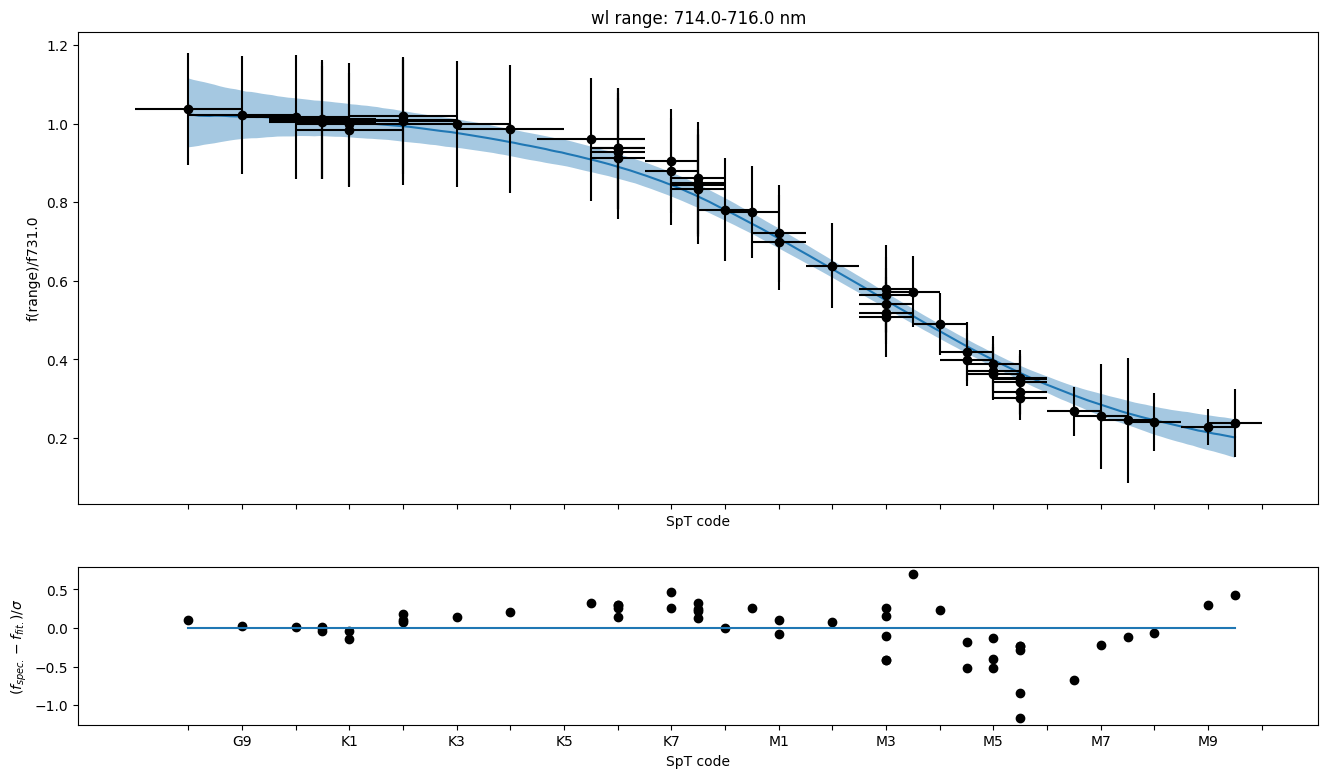

<Figure size 640x480 with 0 Axes>

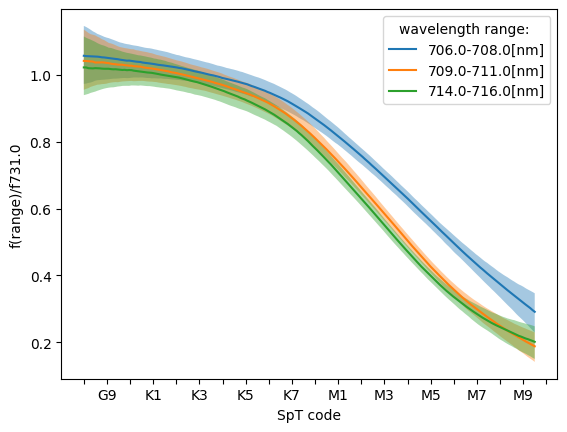

In [2]:
import numpy as np
import frappe.FrappeHelper.PhotFeatures_Ray as pf
import matplotlib.pyplot as plt

#Here you neet to alter the directory that on your machine 
SptFile = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/src/frappe/models_grid/RunnableGrid/summary_classIII_SPTok_SpTErr.txt'
SptInfo = np.genfromtxt(SptFile,usecols=(0,2,4),skip_header=1,dtype=[('Name','U64'),('Spt','U4'),('SptErr','f8')])

#Here you neet to alter the directory that on your machine 
dirSpec = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/src/frappe/models_grid/RunnableGrid/'

nameList = SptInfo['Name']
Spts = SptInfo['Spt']

features = np.array([[335-5,335+5],
                     [340-5,340+5],
                     [357.5-5,357.5+5],
                     [355-6,355+6],#
                     [400-4,400+4], 
                     [450-4,450+4],
                     [475-2,475+2],
                     [461-3,461+3],
                     [703-1,703+1],
                     [707-1,707+1],
                     [710-1,710+1],
                     [715-1,715+1]]
                   )

# compute normalized fluxes and uncertainties withing these ranges
classIIIFeat = pf.classIII()
classIIIFeat.extractFeaturesXS_ray(dirSpec,nameList,Spts,features,WLnorm= 731,SpTErr = SptInfo['SptErr'])

# Choose where you want the outputs!!!
output = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/src/testInterp/' #the output file you want to produce .npz should not be included in the name
#run the non parametric fits
classIIIFeat.nonParamFit_ray(200,1000,rad =2.5,deg =1,outFile = output+'interp.npz')

# the following plots can be produced to inspect the resulting interpolated spectrum
# first the wavelength ranges are plotted individually
plt.figure()
classIIIFeat.plotAllInterpIndividualy(output,close = False)
# plot several different interpolations together
plt.figure()
classIIIFeat.plotInterpTogetherWithErr(output)